In [2]:
!pip install -q seaborn

from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Libraries imported successfully")

 Libraries imported successfully


In [3]:
print("Please upload marketing_campaign_dataset.xlsx")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_excel(filename)
print(f" Dataset loaded: {df.shape} rows and columns")
df.head()

Please upload marketing_campaign_dataset.xlsx


Saving marketing_campaign_dataset.xlsx to marketing_campaign_dataset (1).xlsx
 Dataset loaded: (200000, 16) rows and columns


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_18221/3725336538.py:7: SyntaxWarning: invalid escape sequence '\d'
  df_clean['Duration_Days'] = df_clean['Duration'].str.extract('(\d+)').astype(int)


 Cleaned dataset shape: (200000, 17)


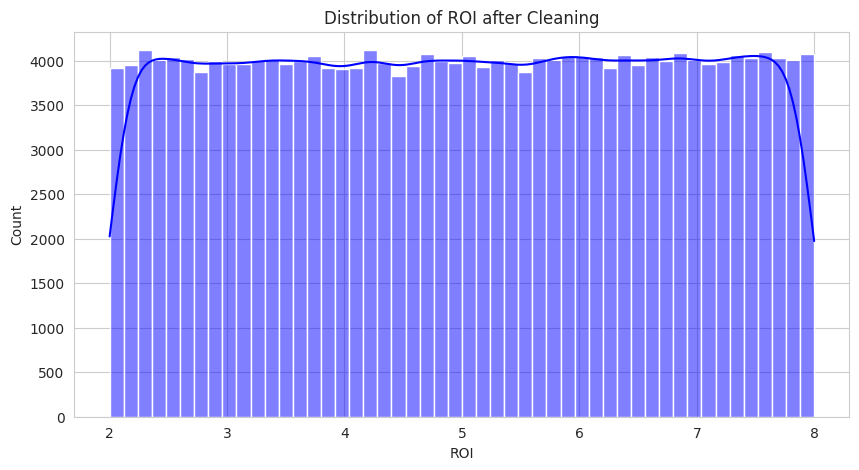

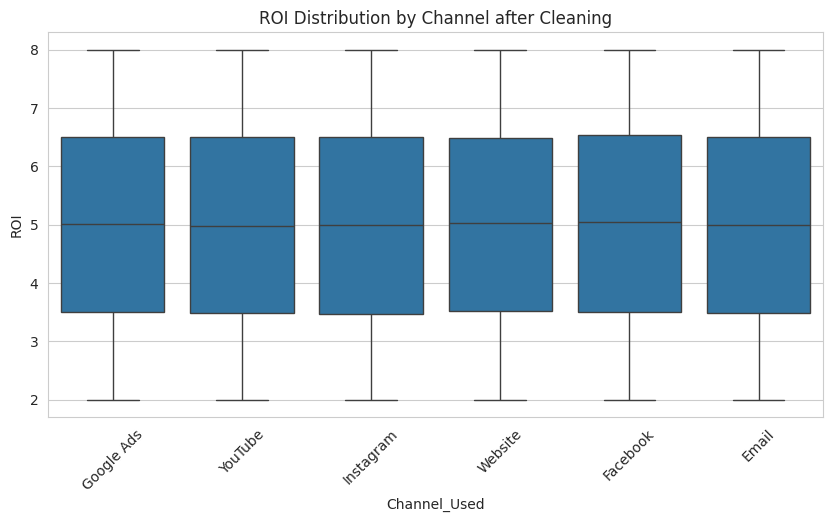

In [6]:
df_clean = df.copy()

if 'Acquisition_Cost' in df_clean.columns:
    df_clean['Acquisition_Cost'] = df_clean['Acquisition_Cost'].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

if 'Duration' in df_clean.columns:
    df_clean['Duration_Days'] = df_clean['Duration'].str.extract('(\d+)').astype(int)

if 'Date' in df_clean.columns:
    df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

df_clean.drop_duplicates(inplace=True)
numeric_cols = df_clean.select_dtypes(include=['number']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print(f" Cleaned dataset shape: {df_clean.shape}")

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['ROI'], bins=50, kde=True, color='blue')
plt.title('Distribution of ROI after Cleaning')
plt.xlabel('ROI')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='Channel_Used', y='ROI', data=df_clean)
plt.title('ROI Distribution by Channel after Cleaning')
plt.xticks(rotation=45)
plt.show()

In [7]:
df_clean = df.copy()

if 'Acquisition_Cost' in df_clean.columns:
    df_clean['Acquisition_Cost'] = df_clean['Acquisition_Cost'].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

if 'Duration' in df_clean.columns:
    df_clean['Duration_Days'] = df_clean['Duration'].str.extract(r'(\d+)').astype(int)

if 'Date' in df_clean.columns:
    df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

df_clean.drop_duplicates(inplace=True)
numeric_cols = df_clean.select_dtypes(include=['number']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print(f" Cleaned dataset shape: {df_clean.shape}")
df_clean.head()

 Cleaned dataset shape: (200000, 17)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Duration_Days
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,30
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,60
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,30
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,60
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,15


=== EDA SUMMARY ===

             ROI  Conversion_Rate  Acquisition_Cost     Clicks  Impressions  \
count  200000.00        200000.00         200000.00  200000.00    200000.00   
mean        5.00             0.08          12504.39     549.77      5507.30   
std         1.73             0.04           4337.66     260.02      2596.86   
min         2.00             0.01           5000.00     100.00      1000.00   
25%         3.50             0.05           8739.75     325.00      3266.00   
50%         5.01             0.08          12496.50     550.00      5517.50   
75%         6.51             0.12          16264.00     775.00      7753.00   
max         8.00             0.15          20000.00    1000.00     10000.00   

       Engagement_Score  
count         200000.00  
mean               5.49  
std                2.87  
min                1.00  
25%                3.00  
50%                5.00  
75%                8.00  
max               10.00  


/tmp/ipykernel_18221/3564289010.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_channels.index, y=top_channels.values, palette='viridis')


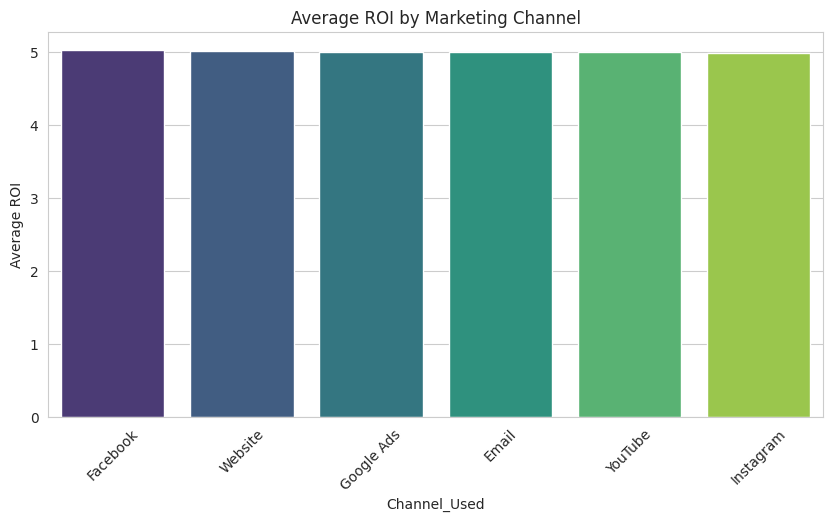

/tmp/ipykernel_18221/3564289010.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='magma')


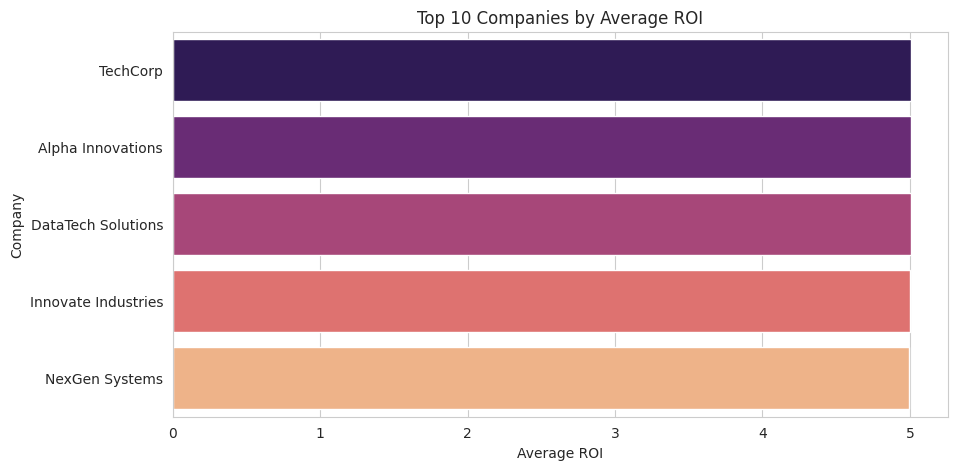

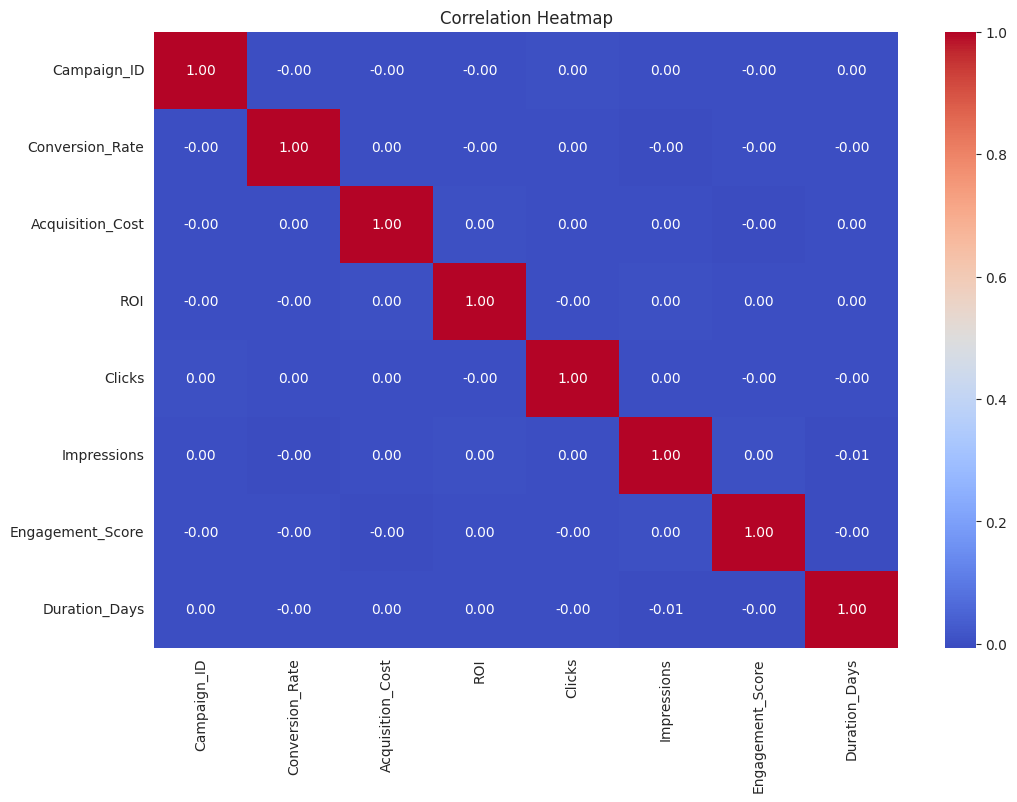

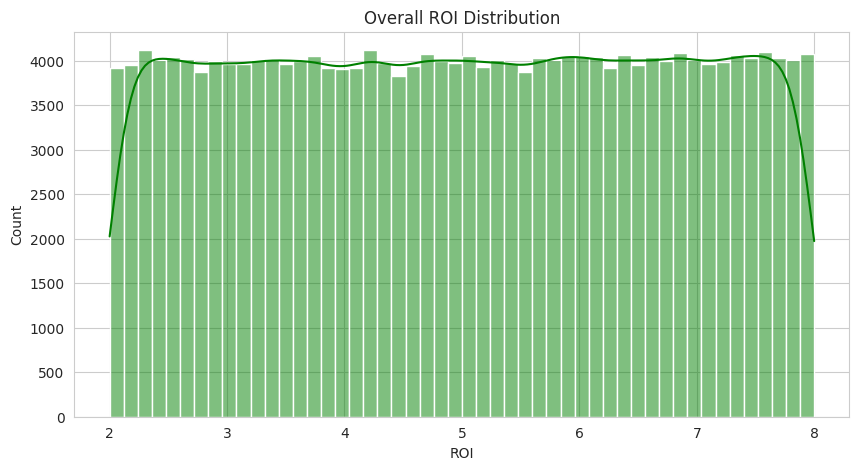

In [8]:
print("=== EDA SUMMARY ===\n")
print(df_clean[['ROI', 'Conversion_Rate', 'Acquisition_Cost', 'Clicks', 'Impressions', 'Engagement_Score']].describe().round(2))

plt.figure(figsize=(10, 5))
top_channels = df_clean.groupby('Channel_Used')['ROI'].mean().sort_values(ascending=False)
sns.barplot(x=top_channels.index, y=top_channels.values, palette='viridis')
plt.title('Average ROI by Marketing Channel')
plt.xticks(rotation=45)
plt.ylabel('Average ROI')
plt.show()

plt.figure(figsize=(10, 5))
top_companies = df_clean.groupby('Company')['ROI'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_companies.values, y=top_companies.index, palette='magma')
plt.title('Top 10 Companies by Average ROI')
plt.xlabel('Average ROI')
plt.show()

plt.figure(figsize=(12, 8))
numeric_df = df_clean.select_dtypes(include=['number'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df_clean['ROI'], bins=50, kde=True, color='green')
plt.title('Overall ROI Distribution')
plt.show()

 Feature Engineering completed. New shape: (200000, 24)


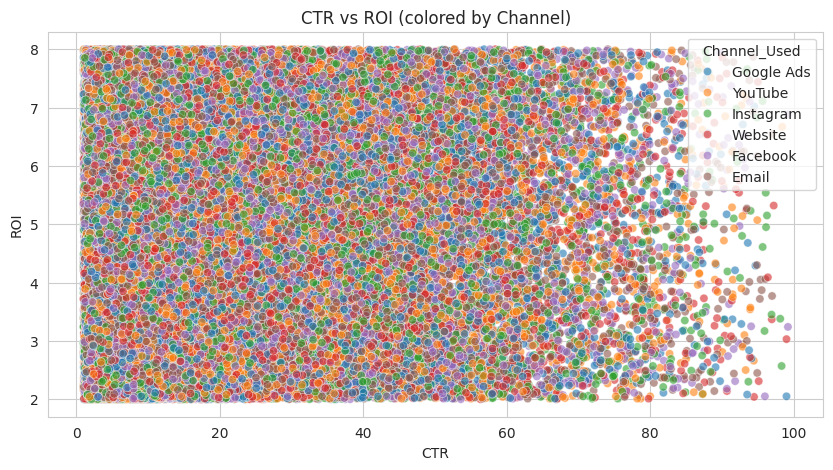

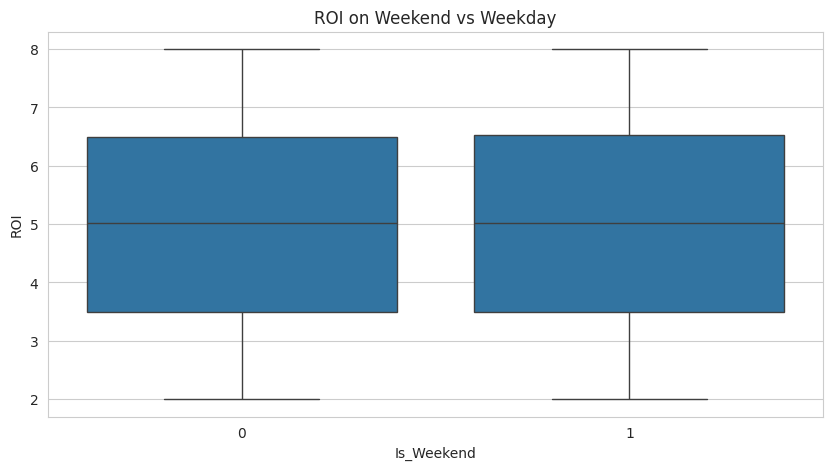

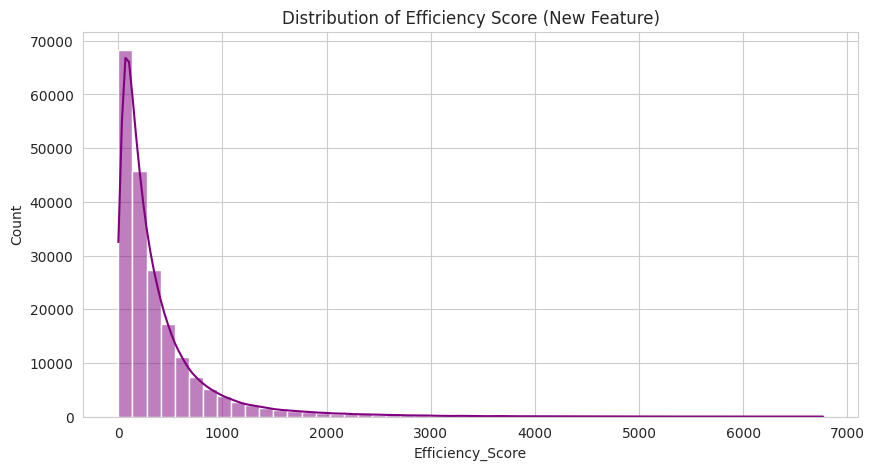

In [10]:
df_eng = df_clean.copy()

df_eng['CTR'] = (df_eng['Clicks'] / df_eng['Impressions'] * 100).round(2)
df_eng['CPC'] = (df_eng['Acquisition_Cost'] / df_eng['Clicks']).replace([np.inf, -np.inf], 0).round(2)
df_eng['Cost_Per_Impression'] = (df_eng['Acquisition_Cost'] / df_eng['Impressions']).round(4)
df_eng['Engagement_per_1000'] = (df_eng['Engagement_Score'] / df_eng['Impressions'] * 1000).round(2)
df_eng['Efficiency_Score'] = (df_eng['ROI'] * df_eng['CTR'] * df_eng['Engagement_Score']).round(2)

df_eng['Day_of_Week'] = df_eng['Date'].dt.day_name()
df_eng['Is_Weekend'] = df_eng['Date'].dt.dayofweek.isin([5, 6]).astype(int)

print(f" Feature Engineering completed. New shape: {df_eng.shape}")

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_eng, x='CTR', y='ROI', hue='Channel_Used', alpha=0.6)
plt.title('CTR vs ROI (colored by Channel)')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='Is_Weekend', y='ROI', data=df_eng)
plt.title('ROI on Weekend vs Weekday')
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(df_eng['Efficiency_Score'], bins=50, kde=True, color='purple')
plt.title('Distribution of Efficiency Score (New Feature)')
plt.show()

Top features correlated with ROI:
ROI                    1.000
Efficiency_Score       0.269
Acquisition_Cost       0.005
CPC                    0.005
Impressions            0.002
CTR                    0.002
Clicks                 0.002
Engagement_per_1000    0.002
Is_Weekend             0.001
Duration_Days          0.001
Conversion_Rate        0.001
Campaign_ID            0.001
Engagement_Score       0.001
Cost_Per_Impression    0.000
Name: ROI, dtype: float64


/tmp/ipykernel_18221/3903810912.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')


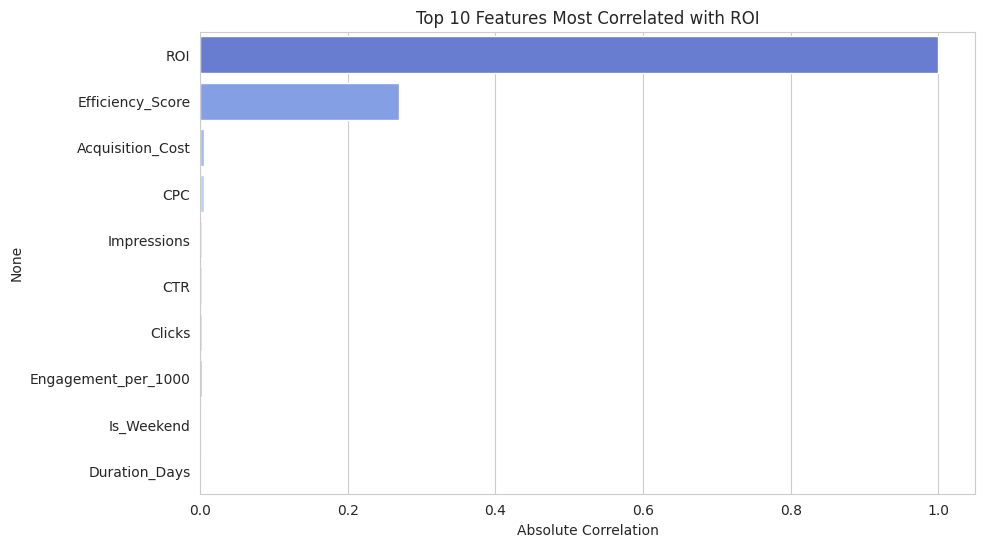

In [11]:
numeric_features = df_eng.select_dtypes(include=['number']).columns
corr_with_roi = df_eng[numeric_features].corr()['ROI'].abs().sort_values(ascending=False)

print("Top features correlated with ROI:")
print(corr_with_roi.round(3))

plt.figure(figsize=(10, 6))
top_corr = corr_with_roi.head(10)
sns.barplot(x=top_corr.values, y=top_corr.index, palette='coolwarm')
plt.title('Top 10 Features Most Correlated with ROI')
plt.xlabel('Absolute Correlation')
plt.show()

In [12]:
df_eng.to_csv("marketing_campaign_cleaned_engineered.csv", index=False)
df_eng.to_excel("marketing_campaign_cleaned_engineered.xlsx", index=False)

print(" Files saved successfully!")

files.download("marketing_campaign_cleaned_engineered.csv")
files.download("marketing_campaign_cleaned_engineered.xlsx")

 Files saved successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>